## Step 0: Fetch MicroStrategy Data

Fetch current MicroStrategy financial data from their investor relations page and SEC filings.


In [ ]:
# ============================================================================
# DATA FETCHING - MicroStrategy Financial Data from strategy.com
# ============================================================================

import json
import re
import os
import requests
from bs4 import BeautifulSoup
import yfinance as yf



def fetch_microstrategy_data():
    """
    Fetch MicroStrategy financial data directly from strategy.com
    """
    print("Fetching MicroStrategy financial data from https://www.strategy.com/...")
    data = {}
    
    try:
        url = "https://www.strategy.com/"
        headers = {
            'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8'
        }
        response = requests.get(url, headers=headers, timeout=15)
        
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            
            # Find the __NEXT_DATA__ script tag containing all the data
            script_tag = soup.find('script', {'id': '__NEXT_DATA__'})
            
            if script_tag:
                next_data = json.loads(script_tag.string)
                
                # Extract btcTrackerData from the JSON structure
                btc_tracker_data = next_data.get('props', {}).get('pageProps', {}).get('btcTrackerData', [])
                
                if btc_tracker_data and len(btc_tracker_data) > 0:
                    latest_data = btc_tracker_data[0]  # Get the latest entry
                    
                    # Extract Bitcoin holdings
                    if 'btc_holdings' in latest_data:
                        data['bitcoin_holdings'] = int(latest_data['btc_holdings'])
                        print(f"  ✓ Bitcoin holdings: {data['bitcoin_holdings']:,} BTC")
                    
                    # Extract cash reserve
                    if 'cash' in latest_data:
                        data['cash'] = float(latest_data['cash'])
                        print(f"  ✓ Cash reserve: ${data['cash']:,.0f}")
                    
                    # Extract STRC preferred stock data
                    if 'strc_metrics' in latest_data:
                        strc = latest_data['strc_metrics']
                        if 'shares' in strc:
                            data['strc_shares'] = int(strc['shares'])
                            print(f"  ✓ STRC shares outstanding: {data['strc_shares']:,}")
                        if 'dividend' in strc:
                            data['strc_dividend_rate'] = float(strc['dividend']) / 100.0  # Convert from percentage
                            print(f"  ✓ STRC dividend rate: {data['strc_dividend_rate']:.2%}")
                    
                    # Extract other preferred stock data (STRD, STRE, STRK, STRF)
                    preferred_series = ['strd', 'stre', 'strk', 'strf']
                    total_other_annual_dividend = 0
                    
                    for series in preferred_series:
                        metrics_key = f'{series}_metrics'
                        if metrics_key in latest_data:
                            series_data = latest_data[metrics_key]
                            if 'shares' in series_data and 'dividend' in series_data:
                                shares = int(series_data['shares'])
                                dividend_rate = float(series_data['dividend']) / 100.0  # Convert from percentage
                                
                                # Store individual series data
                                data[f'{series}_shares'] = shares
                                data[f'{series}_dividend_rate'] = dividend_rate
                                
                                # Calculate annual dividend: shares * par_value * dividend_rate
                                par_value = 100  # Standard par value
                                annual_dividend = shares * par_value * dividend_rate
                                data[f'{series}_annual_dividend'] = annual_dividend
                                
                                # Add to total
                                total_other_annual_dividend += annual_dividend
                                
                                print(f"  ✓ {series.upper()} shares: {shares:,}, dividend: {dividend_rate:.2%}, annual: ${annual_dividend:,.0f}")
                    
                    # Store total other preferred annual and monthly dividends
                    data['other_preferred_annual_dividend'] = total_other_annual_dividend
                    data['other_preferred_monthly_dividend'] = total_other_annual_dividend / 12.0
                    
                    if total_other_annual_dividend > 0:
                        print(f"  ✓ Total other preferred annual dividend: ${total_other_annual_dividend:,.0f}")
                        print(f"  ✓ Total other preferred monthly dividend: ${data['other_preferred_monthly_dividend']:,.0f}")
                    
                    print(f"  ✓ Data date: {latest_data.get('as_of_date', 'N/A')}")
                else:
                    print("  ✗ No btcTrackerData found in response")
            else:
                print("  ✗ Could not find __NEXT_DATA__ script tag")
        else:
            print(f"  ✗ HTTP {response.status_code}: Could not fetch from strategy.com")
            
    except Exception as e:
        print(f"  ✗ Error fetching from strategy.com: {e}")
        import traceback
        traceback.print_exc()
    
    return data

# Fetch data
mstr_data = fetch_microstrategy_data()


Fetching MicroStrategy financial data from https://www.strategy.com/...
  ✓ Bitcoin holdings: 671,268 BTC
  ✓ Cash reserve: $1,440,000,000
  ✓ STRC shares outstanding: 29,587,063
  ✓ STRC dividend rate: 10.75%
  ✓ STRD shares: 14,024,221, dividend: 10.00%, annual: $140,242,210
  ✓ STRE shares: 9,099,275, dividend: 10.00%, annual: $90,992,750
  ✓ STRK shares: 13,981,948, dividend: 8.00%, annual: $111,855,584
  ✓ STRF shares: 12,839,689, dividend: 10.00%, annual: $128,396,890
  ✓ Total other preferred annual dividend: $471,487,434
  ✓ Total other preferred monthly dividend: $39,290,620
  ✓ Data date: 2025-12-15


# STRC Preferred Equity Valuation Model

This notebook values STRC preferred stock by discounting future dividends, where dividends are funded by Bitcoin sales after cash reserves are depleted. Bitcoin price paths are loaded from `btc_price_paths.json`, which is generated by `btc_price_paths.ipynb` using a manual normal-based distribution with adjustable parameters.


In [11]:
# ============================================================================
# CONFIGURATION SECTION - ALL ADJUSTABLE PARAMETERS
# ============================================================================

# ----------------------------------------------------------------------------
# Simulation Parameters
# ----------------------------------------------------------------------------
NUM_SIMULATIONS = 10000          # Number of Monte Carlo simulation runs
SIMULATION_YEARS = 100           # Projection period in years
MEAN_CAGR = 0.0                  # Mean Compound Annual Growth Rate (Bitcoin trends to zero)

# ----------------------------------------------------------------------------
# STRC Preferred Stock Parameters
# ----------------------------------------------------------------------------
# Use fetched data if available, otherwise use defaults
STRC_SHARES_OUTSTANDING = mstr_data.get('strc_shares', 28011111)  # Total STRC shares outstanding
STRC_ANNUAL_DIVIDEND_RATE = mstr_data.get('strc_dividend_rate', 0.1075)  # Annual dividend rate (from strategy.com)
STRC_PAR_VALUE = 100                  # Par value per share in USD ($100)

# Calculate total STRC dividend obligations
STRC_MONTHLY_DIVIDEND_PER_SHARE = STRC_ANNUAL_DIVIDEND_RATE * STRC_PAR_VALUE / 12
STRC_MONTHLY_DIVIDEND_TOTAL = STRC_MONTHLY_DIVIDEND_PER_SHARE * STRC_SHARES_OUTSTANDING
STRC_ANNUAL_DIVIDEND_TOTAL = STRC_ANNUAL_DIVIDEND_RATE * STRC_PAR_VALUE * STRC_SHARES_OUTSTANDING

# ----------------------------------------------------------------------------
# Other Preferred Share Obligations (STRD, STRE, STRK, STRF)
# ----------------------------------------------------------------------------
# Note: These obligations remain constant across all simulations
# Calculated from strategy.com data
OTHER_PREFERRED_MONTHLY_DIVIDEND = mstr_data.get('other_preferred_monthly_dividend', 0)  # Total monthly dividend obligation for other preferred shares in USD
OTHER_PREFERRED_ANNUAL_DIVIDEND = mstr_data.get('other_preferred_annual_dividend', 0)  # Total annual dividend obligation

# Individual series data (for reference)
STRD_SHARES = mstr_data.get('strd_shares', 0)
STRD_DIVIDEND_RATE = mstr_data.get('strd_dividend_rate', 0)
STRD_ANNUAL_DIVIDEND = mstr_data.get('strd_annual_dividend', 0)

STRE_SHARES = mstr_data.get('stre_shares', 0)
STRE_DIVIDEND_RATE = mstr_data.get('stre_dividend_rate', 0)
STRE_ANNUAL_DIVIDEND = mstr_data.get('stre_annual_dividend', 0)

STRK_SHARES = mstr_data.get('strk_shares', 0)
STRK_DIVIDEND_RATE = mstr_data.get('strk_dividend_rate', 0)
STRK_ANNUAL_DIVIDEND = mstr_data.get('strk_annual_dividend', 0)

STRF_SHARES = mstr_data.get('strf_shares', 0)
STRF_DIVIDEND_RATE = mstr_data.get('strf_dividend_rate', 0)
STRF_ANNUAL_DIVIDEND = mstr_data.get('strf_annual_dividend', 0)

# Total dividend obligations (STRC + Other Preferred)
# IMPORTANT: This includes BOTH STRC and all other preferred stock obligations
TOTAL_MONTHLY_DIVIDEND_OBLIGATION = STRC_MONTHLY_DIVIDEND_TOTAL + OTHER_PREFERRED_MONTHLY_DIVIDEND
TOTAL_ANNUAL_DIVIDEND_OBLIGATION = STRC_ANNUAL_DIVIDEND_TOTAL + OTHER_PREFERRED_ANNUAL_DIVIDEND

# ----------------------------------------------------------------------------
# Bitcoin Price Configuration
# ----------------------------------------------------------------------------
USE_CUSTOM_BITCOIN_PRICE = False  # Set to True to use custom price instead of fetching from Yahoo Finance
CUSTOM_BITCOIN_PRICE = 110000     # Custom Bitcoin price (only used if USE_CUSTOM_BITCOIN_PRICE = True)

# Fetch current Bitcoin price from Yahoo Finance (unless override is enabled)
btc_price_source = None
if USE_CUSTOM_BITCOIN_PRICE:
    CURRENT_BITCOIN_PRICE = CUSTOM_BITCOIN_PRICE
    btc_price_source = "Custom (override enabled)"
else:
    try:
        btc_ticker = yf.Ticker("BTC-USD")
        btc_data = btc_ticker.history(period="1d")
        if len(btc_data) > 0:
            CURRENT_BITCOIN_PRICE = float(btc_data['Close'].iloc[-1])
            btc_price_source = "Yahoo Finance (success)"
        else:
            CURRENT_BITCOIN_PRICE = 110000  # Fallback default
            btc_price_source = "Default (Yahoo Finance returned no data)"
    except Exception as e:
        CURRENT_BITCOIN_PRICE = 110000  # Fallback default
        btc_price_source = f"Default (Yahoo Finance error: {str(e)[:50]})"

# ----------------------------------------------------------------------------
# MSTR Company Parameters
# ----------------------------------------------------------------------------
# Use fetched data if available, otherwise use defaults
INITIAL_BITCOIN_HOLDINGS = mstr_data.get('bitcoin_holdings', 649870)  # Initial Bitcoin holdings (number of BTC)
INITIAL_CASH_RESERVE = mstr_data.get('cash', 100000000)  # Initial cash reserve in USD

print(f"\nBitcoin Price: ${CURRENT_BITCOIN_PRICE:,.2f} ({btc_price_source})")

# ----------------------------------------------------------------------------
# Financial Parameters
# ----------------------------------------------------------------------------
DISCOUNT_RATE_ANNUAL = 0.04786           # Annual discount rate for NPV calculation (10%)
MONTHLY_DISCOUNT_RATE = (1 + DISCOUNT_RATE_ANNUAL) ** (1/12) - 1  # Monthly discount rate

# ----------------------------------------------------------------------------
# Note: Bitcoin price paths are loaded from btc_price_paths.json
# Run btc_price_paths.ipynb first to generate the price paths
# ----------------------------------------------------------------------------

# ----------------------------------------------------------------------------
# Display Configuration Summary
# ----------------------------------------------------------------------------
print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Simulations: {NUM_SIMULATIONS:,}")
print(f"Projection Period: {SIMULATION_YEARS} years")
print(f"Mean CAGR: {MEAN_CAGR:.1%}")
print(f"\nSTRC Preferred Stock:")
print(f"  Shares Outstanding: {STRC_SHARES_OUTSTANDING:,}")
print(f"  Dividend Rate: {STRC_ANNUAL_DIVIDEND_RATE:.2%}")
print(f"  Monthly Dividend per Share: ${STRC_MONTHLY_DIVIDEND_PER_SHARE:.3f}")
print(f"  Total Annual Dividend: ${STRC_ANNUAL_DIVIDEND_TOTAL:,.2f}")
print(f"  Total Monthly Dividend: ${STRC_MONTHLY_DIVIDEND_TOTAL:,.2f}")

print(f"\nOther Preferred Stock (STRD, STRE, STRK, STRF):")
if STRD_SHARES > 0:
    print(f"  STRD: {STRD_SHARES:,} shares @ {STRD_DIVIDEND_RATE:.2%} = ${STRD_ANNUAL_DIVIDEND:,.0f}/year = ${STRD_ANNUAL_DIVIDEND/12:,.2f}/month")
if STRE_SHARES > 0:
    print(f"  STRE: {STRE_SHARES:,} shares @ {STRE_DIVIDEND_RATE:.2%} = ${STRE_ANNUAL_DIVIDEND:,.0f}/year = ${STRE_ANNUAL_DIVIDEND/12:,.2f}/month")
if STRK_SHARES > 0:
    print(f"  STRK: {STRK_SHARES:,} shares @ {STRK_DIVIDEND_RATE:.2%} = ${STRK_ANNUAL_DIVIDEND:,.0f}/year = ${STRK_ANNUAL_DIVIDEND/12:,.2f}/month")
if STRF_SHARES > 0:
    print(f"  STRF: {STRF_SHARES:,} shares @ {STRF_DIVIDEND_RATE:.2%} = ${STRF_ANNUAL_DIVIDEND:,.0f}/year = ${STRF_ANNUAL_DIVIDEND/12:,.2f}/month")
print(f"  Total Other Preferred Annual: ${OTHER_PREFERRED_ANNUAL_DIVIDEND:,.2f}")
print(f"  Total Other Preferred Monthly: ${OTHER_PREFERRED_MONTHLY_DIVIDEND:,.2f}")

print(f"\n" + "="*70)
print(f"TOTAL DIVIDEND OBLIGATIONS (STRC + Other Preferred)")
print("="*70)
print(f"  Total Annual Dividend Obligation: ${TOTAL_ANNUAL_DIVIDEND_OBLIGATION:,.2f}")
print(f"    - STRC: ${STRC_ANNUAL_DIVIDEND_TOTAL:,.2f}")
print(f"    - Other Preferred (STRD+STRE+STRK+STRF): ${OTHER_PREFERRED_ANNUAL_DIVIDEND:,.2f}")
print(f"  Total Monthly Dividend Obligation: ${TOTAL_MONTHLY_DIVIDEND_OBLIGATION:,.2f}")
print(f"    - STRC: ${STRC_MONTHLY_DIVIDEND_TOTAL:,.2f}")
print(f"    - Other Preferred (STRD+STRE+STRK+STRF): ${OTHER_PREFERRED_MONTHLY_DIVIDEND:,.2f}")
print("="*70)
print(f"\nInitial Bitcoin Holdings: {INITIAL_BITCOIN_HOLDINGS:,} BTC")
print(f"Initial Cash Reserve: ${INITIAL_CASH_RESERVE:,.2f}")
print(f"Current Bitcoin Price: ${CURRENT_BITCOIN_PRICE:,.2f}")
print(f"\nDiscount Rate (Annual): {DISCOUNT_RATE_ANNUAL:.1%}")
print(f"Note: Bitcoin price paths will be loaded from btc_price_paths.json")
print("=" * 70)



Bitcoin Price: $86,891.27 (Yahoo Finance (success))
CONFIGURATION SUMMARY
Simulations: 10,000
Projection Period: 100 years
Mean CAGR: 0.0%

STRC Preferred Stock:
  Shares Outstanding: 29,587,063
  Dividend Rate: 10.75%
  Monthly Dividend per Share: $0.896
  Total Annual Dividend: $318,060,927.25
  Total Monthly Dividend: $26,505,077.27

Other Preferred Stock (STRD, STRE, STRK, STRF):
  STRD: 14,024,221 shares @ 10.00% = $140,242,210/year = $11,686,850.83/month
  STRE: 9,099,275 shares @ 10.00% = $90,992,750/year = $7,582,729.17/month
  STRK: 13,981,948 shares @ 8.00% = $111,855,584/year = $9,321,298.67/month
  STRF: 12,839,689 shares @ 10.00% = $128,396,890/year = $10,699,740.83/month
  Total Other Preferred Annual: $471,487,434.00
  Total Other Preferred Monthly: $39,290,619.50

TOTAL DIVIDEND OBLIGATIONS (STRC + Other Preferred)
  Total Annual Dividend Obligation: $789,548,361.25
    - STRC: $318,060,927.25
    - Other Preferred (STRD+STRE+STRK+STRF): $471,487,434.00
  Total Monthly

In [12]:
# ============================================================================
# IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma
try:
    from numba import jit, prange
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    print("Note: numba not available. Install with: pip install numba (for faster simulation)")
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Load Bitcoin Price Paths

Load pre-generated Bitcoin price paths from JSON file. The paths are generated by `btc_price_paths.ipynb` using a manual normal-based distribution with adjustable parameters.


Loading Bitcoin price paths from btc_price_paths.json...
✓ Successfully loaded price paths!
  Number of simulations: 10,000
  Simulation period: 100 years (1,200 months)
  Initial Bitcoin price: $86,902.43

Distribution parameters used:
  Mean: -0.0040
  Std Dev: 0.1300
  Skewness: 0.0000
  Excess Kurtosis: 3.0000
  Tail Weight: 1.0000
  Asymmetry: 0.0000

Price statistics across all simulations:
  Initial price: $86,902.43
  Final price (mean): $148,133,138.91
  Final price (median): $895.22
  Final price (std): $5,180,431,248.81
  Final price (min): $0.01
  Final price (max): $406,888,288,385.81

10-Year Scenario Analysis (from $86,902.43):
  Price <= $1,000: 102 simulations (1.0%)
  Price <= $100: 2 simulations (0.0%)
  Price <= $10: 0 simulations (0.0%)
  10-year min: $54.46
  10-year max: $35,552,147.11
  10-year median: $54,260.40

100-Year Extreme Scenario Analysis:
  Final price >= $1M: 948 simulations (9.5%)
  Final price >= $100K: 1,895 simulations (18.9%)
  Final price <= $1

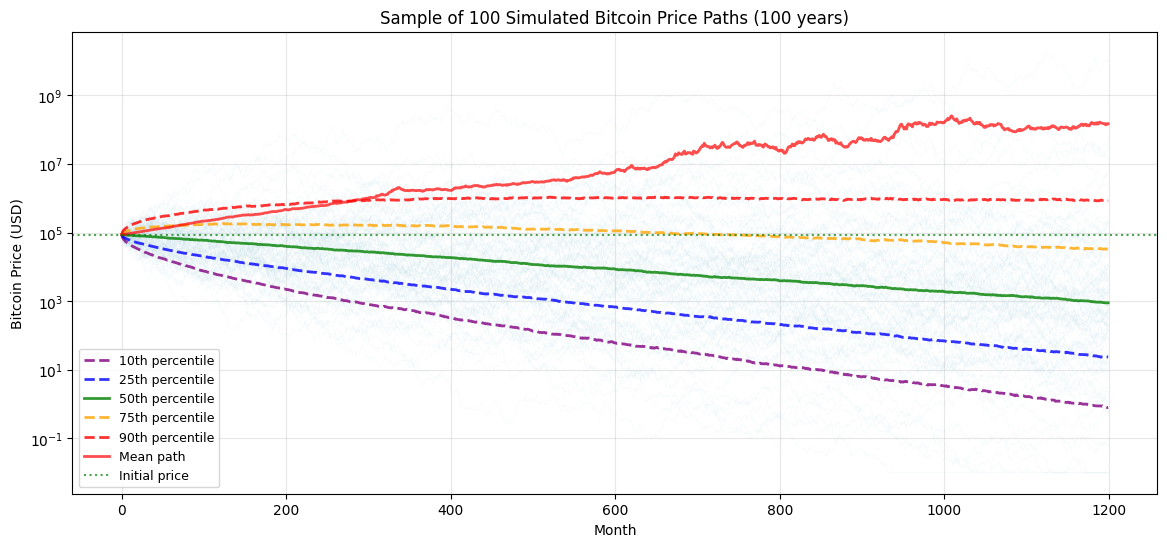

In [13]:
# ============================================================================
# LOAD BITCOIN PRICE PATHS FROM JSON
# ============================================================================

import json
import os

# Load price paths from JSON file
json_file = "btc_price_paths.json"

if not os.path.exists(json_file):
    raise FileNotFoundError(
        f"Error: {json_file} not found!\n"
        f"Please run btc_price_paths.ipynb first to generate the price paths."
    )

print(f"Loading Bitcoin price paths from {json_file}...")

with open(json_file, 'r') as f:
    price_data = json.load(f)

# Extract data
NUM_SIMULATIONS = price_data['num_simulations']
SIMULATION_YEARS = price_data['simulation_years']
TOTAL_MONTHS = price_data['total_months']
CURRENT_BITCOIN_PRICE = price_data['initial_price']
distribution_params = price_data['distribution_params']
simulated_prices = np.array(price_data['price_paths'])

# Verify dimensions
expected_shape = (NUM_SIMULATIONS, TOTAL_MONTHS)
if simulated_prices.shape != expected_shape:
    raise ValueError(
        f"Error: Price paths shape mismatch!\n"
        f"Expected: {expected_shape}, Got: {simulated_prices.shape}"
    )

MONTHS_PER_YEAR = 12

print(f"✓ Successfully loaded price paths!")
print(f"  Number of simulations: {NUM_SIMULATIONS:,}")
print(f"  Simulation period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
print(f"  Initial Bitcoin price: ${CURRENT_BITCOIN_PRICE:,.2f}")
print(f"\nDistribution parameters used:")
print(f"  Mean: {distribution_params['mean']:.4f}")
print(f"  Std Dev: {distribution_params['std']:.4f}")
print(f"  Skewness: {distribution_params['skew']:.4f}")
print(f"  Excess Kurtosis: {distribution_params['kurtosis']:.4f}")
print(f"  Tail Weight: {distribution_params['tail_weight']:.4f}")
print(f"  Asymmetry: {distribution_params['asymmetry']:.4f}")

# Display statistics
print(f"\nPrice statistics across all simulations:")
print(f"  Initial price: ${CURRENT_BITCOIN_PRICE:,.2f}")
print(f"  Final price (mean): ${simulated_prices[:, -1].mean():,.2f}")
print(f"  Final price (median): ${np.median(simulated_prices[:, -1]):,.2f}")
print(f"  Final price (std): ${simulated_prices[:, -1].std():,.2f}")
print(f"  Final price (min): ${simulated_prices[:, -1].min():,.2f}")
print(f"  Final price (max): ${simulated_prices[:, -1].max():,.2f}")

# Analyze extreme scenarios
final_prices = simulated_prices[:, -1]
extreme_high = (final_prices >= 1000000).sum()  # >= $1M
very_high = (final_prices >= 100000).sum()  # >= $100K
extreme_low = (final_prices <= 100).sum()  # <= $100
very_low = (final_prices <= 10).sum()  # <= $10
near_zero = (final_prices <= 1).sum()  # <= $1

# 10-year analysis (120 months)
ten_year_prices = simulated_prices[:, 120] if TOTAL_MONTHS >= 120 else simulated_prices[:, -1]
ten_year_drop_1000 = (ten_year_prices <= 1000).sum()
ten_year_drop_100 = (ten_year_prices <= 100).sum()
ten_year_drop_10 = (ten_year_prices <= 10).sum()

print(f"\n10-Year Scenario Analysis (from ${CURRENT_BITCOIN_PRICE:,.2f}):")
print(f"  Price <= $1,000: {ten_year_drop_1000:,} simulations ({ten_year_drop_1000/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Price <= $100: {ten_year_drop_100:,} simulations ({ten_year_drop_100/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Price <= $10: {ten_year_drop_10:,} simulations ({ten_year_drop_10/NUM_SIMULATIONS*100:.1f}%)")
print(f"  10-year min: ${ten_year_prices.min():,.2f}")
print(f"  10-year max: ${ten_year_prices.max():,.2f}")
print(f"  10-year median: ${np.median(ten_year_prices):,.2f}")

print(f"\n{SIMULATION_YEARS}-Year Extreme Scenario Analysis:")
print(f"  Final price >= $1M: {extreme_high:,} simulations ({extreme_high/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Final price >= $100K: {very_high:,} simulations ({very_high/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Final price <= $100: {extreme_low:,} simulations ({extreme_low/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Final price <= $10: {very_low:,} simulations ({very_low/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Final price <= $1: {near_zero:,} simulations ({near_zero/NUM_SIMULATIONS*100:.1f}%)")
print(f"  Final price <= $0.01: {(final_prices <= 0.01).sum():,} simulations ({(final_prices <= 0.01).sum()/NUM_SIMULATIONS*100:.1f}%)")

# Plot sample of simulated paths with percentiles
plt.figure(figsize=(14, 6))
sample_paths = min(100, NUM_SIMULATIONS)
for i in range(sample_paths):
    plt.plot(simulated_prices[i, :], alpha=0.1, linewidth=0.5, color='lightblue')

# Calculate percentiles across all simulations at each time point
percentiles = [10, 25, 50, 75, 90]
percentile_paths = {}
percentile_colors = {
    10: 'purple',
    25: 'blue',
    50: 'green',
    75: 'orange',
    90: 'red'
}
percentile_styles = {
    10: '--',
    25: '--',
    50: '-',  # Median gets solid line
    75: '--',
    90: '--'
}

for p in percentiles:
    percentile_paths[p] = np.percentile(simulated_prices, p, axis=0)
    plt.plot(percentile_paths[p], 
             color=percentile_colors[p], 
             linestyle=percentile_styles[p],
             linewidth=2, 
             label=f'{p}th percentile',
             alpha=0.8)

plt.plot(simulated_prices.mean(axis=0), 'r-', linewidth=2, label='Mean path', alpha=0.7)
plt.axhline(y=CURRENT_BITCOIN_PRICE, color='g', linestyle=':', linewidth=1.5, label='Initial price', alpha=0.7)
plt.title(f'Sample of {sample_paths} Simulated Bitcoin Price Paths ({SIMULATION_YEARS} years)')
plt.xlabel('Month')
plt.ylabel('Bitcoin Price (USD)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()


## Step 2: Dividend Payment Logic

For each simulation, calculate how long dividends can be paid:
1. First, draw down cash reserve
2. Then, sell Bitcoin to cover dividend obligations
3. Track Bitcoin holdings depletion


Calculating dividend sustainability for 10,000 simulations...

Total Dividend Obligations:
  Total Annual: $789,548,361.25
    - STRC: $318,060,927.25
    - Other Preferred (STRD+STRE+STRK+STRF): $471,487,434.00
  Total Monthly: $65,795,696.77
    - STRC: $26,505,077.27
    - Other Preferred (STRD+STRE+STRK+STRF): $39,290,619.50
  Processed 1,000 simulations...
  Processed 2,000 simulations...
  Processed 3,000 simulations...
  Processed 4,000 simulations...
  Processed 5,000 simulations...
  Processed 6,000 simulations...
  Processed 7,000 simulations...
  Processed 8,000 simulations...
  Processed 9,000 simulations...
  Processed 10,000 simulations...

DIVIDEND SUSTAINABILITY RESULTS
Average months dividends paid: 459.5
Median months dividends paid: 319.5
Min months dividends paid: 51
Max months dividends paid: 1200

Simulations that paid full 1200 months: 1,094 (10.9%)
Simulations that paid < 12 months: 0 (0.0%)


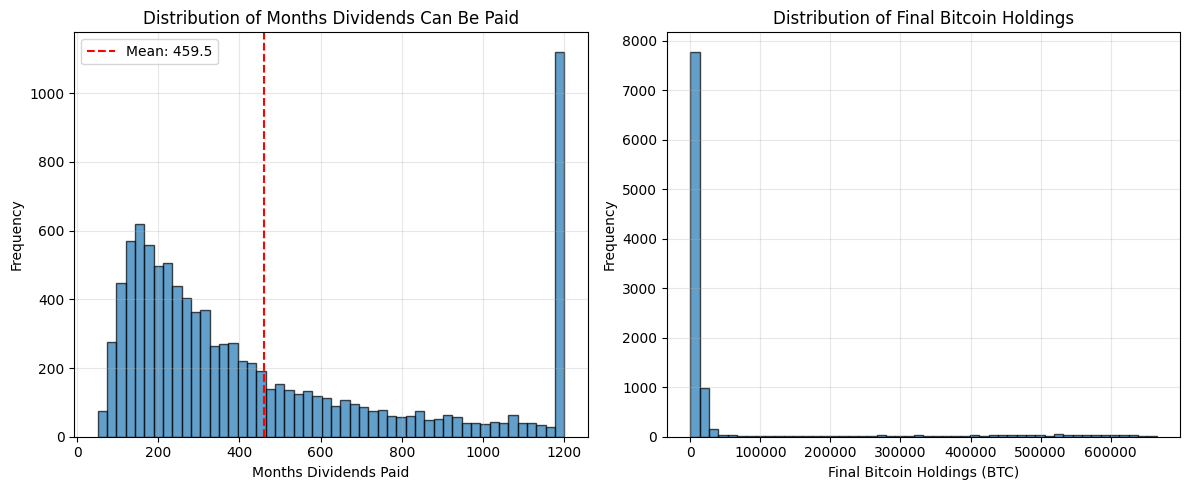

In [14]:
# Initialize arrays to store results
months_dividends_paid = np.zeros(NUM_SIMULATIONS)
final_bitcoin_holdings = np.zeros(NUM_SIMULATIONS)
final_cash_reserve = np.zeros(NUM_SIMULATIONS)

print(f"Calculating dividend sustainability for {NUM_SIMULATIONS:,} simulations...")
print(f"\nTotal Dividend Obligations:")
print(f"  Total Annual: ${TOTAL_ANNUAL_DIVIDEND_OBLIGATION:,.2f}")
print(f"    - STRC: ${STRC_ANNUAL_DIVIDEND_TOTAL:,.2f}")
print(f"    - Other Preferred (STRD+STRE+STRK+STRF): ${OTHER_PREFERRED_ANNUAL_DIVIDEND:,.2f}")
print(f"  Total Monthly: ${TOTAL_MONTHLY_DIVIDEND_OBLIGATION:,.2f}")
print(f"    - STRC: ${STRC_MONTHLY_DIVIDEND_TOTAL:,.2f}")
print(f"    - Other Preferred (STRD+STRE+STRK+STRF): ${OTHER_PREFERRED_MONTHLY_DIVIDEND:,.2f}")

# Process each simulation
for sim in range(NUM_SIMULATIONS):
    cash_reserve = INITIAL_CASH_RESERVE
    bitcoin_holdings = INITIAL_BITCOIN_HOLDINGS
    months_paid = 0
    
    for month in range(TOTAL_MONTHS):
        # Get Bitcoin price for this month
        btc_price = simulated_prices[sim, month]
        
        # Calculate total dividend obligation for this month
        total_dividend_needed = TOTAL_MONTHLY_DIVIDEND_OBLIGATION
        
        # Phase 1: Pay from cash reserve first
        if cash_reserve >= total_dividend_needed:
            cash_reserve -= total_dividend_needed
            months_paid += 1
        else:
            # Phase 2: Need to sell Bitcoin
            shortfall = total_dividend_needed - cash_reserve
            cash_reserve = 0  # Exhaust cash reserve
            
            # Calculate Bitcoin needed to cover shortfall
            btc_needed = shortfall / btc_price if btc_price > 0 else float('inf')
            
            if bitcoin_holdings >= btc_needed:
                # Can pay dividend by selling Bitcoin
                bitcoin_holdings -= btc_needed
                months_paid += 1
            else:
                # Cannot pay dividend - Bitcoin reserves exhausted
                break
    
    months_dividends_paid[sim] = months_paid
    final_bitcoin_holdings[sim] = bitcoin_holdings
    final_cash_reserve[sim] = cash_reserve
    
    # Progress indicator
    if (sim + 1) % 1000 == 0:
        print(f"  Processed {sim + 1:,} simulations...")

print(f"\n" + "=" * 70)
print("DIVIDEND SUSTAINABILITY RESULTS")
print("=" * 70)
print(f"Average months dividends paid: {months_dividends_paid.mean():.1f}")
print(f"Median months dividends paid: {np.median(months_dividends_paid):.1f}")
print(f"Min months dividends paid: {months_dividends_paid.min():.0f}")
print(f"Max months dividends paid: {months_dividends_paid.max():.0f}")
print(f"\nSimulations that paid full {TOTAL_MONTHS} months: {(months_dividends_paid == TOTAL_MONTHS).sum():,} ({(months_dividends_paid == TOTAL_MONTHS).mean()*100:.1f}%)")
print(f"Simulations that paid < 12 months: {(months_dividends_paid < 12).sum():,} ({(months_dividends_paid < 12).mean()*100:.1f}%)")

# Plot distribution of months paid
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(months_dividends_paid, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(months_dividends_paid.mean(), color='r', linestyle='--', label=f'Mean: {months_dividends_paid.mean():.1f}')
plt.xlabel('Months Dividends Paid')
plt.ylabel('Frequency')
plt.title('Distribution of Months Dividends Can Be Paid')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(final_bitcoin_holdings, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Final Bitcoin Holdings (BTC)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Bitcoin Holdings')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 3: NPV Calculation

For each simulation, calculate the Net Present Value of all dividend payments.


Calculating NPV for 10,000 simulations...
Discount rate (annual): 4.8%
Discount rate (monthly): 0.3903%
  Processed 1,000 simulations...
  Processed 2,000 simulations...
  Processed 3,000 simulations...
  Processed 4,000 simulations...
  Processed 5,000 simulations...
  Processed 6,000 simulations...
  Processed 7,000 simulations...
  Processed 8,000 simulations...
  Processed 9,000 simulations...
  Processed 10,000 simulations...

NPV CALCULATION RESULTS
Average NPV (total): $4,762,437,873.09
Average NPV per share: $160.96
Median NPV per share: $163.40
Std Dev NPV per share: $50.59

NPV Statistics (per share):
  5th percentile: $77.05
  25th percentile: $118.74
  75th percentile: $210.01
  95th percentile: $227.36


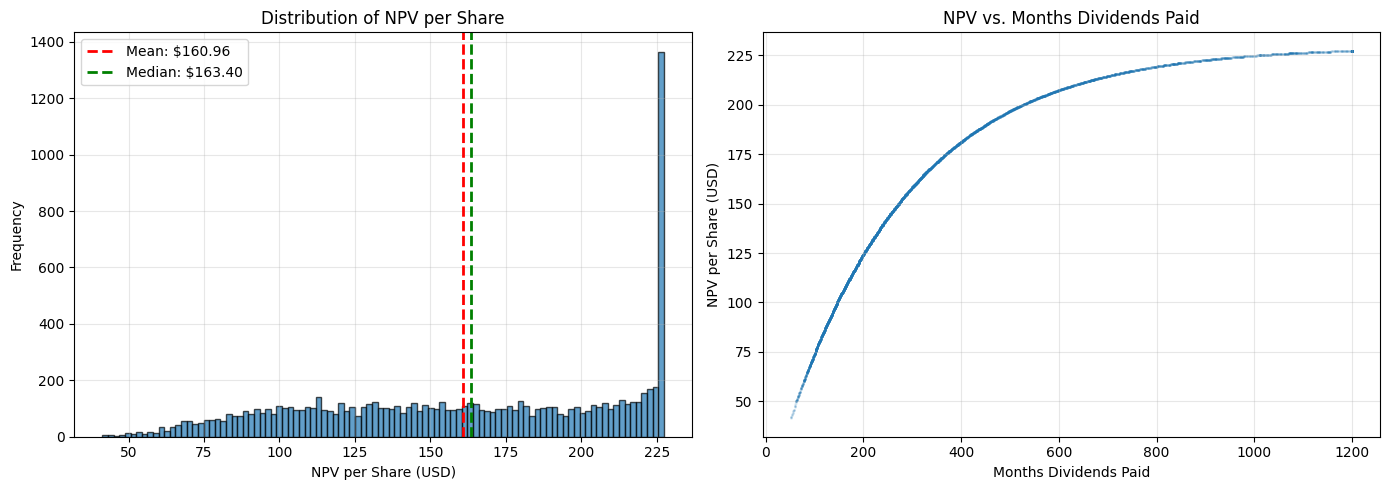

In [15]:
# Calculate NPV for each simulation
npvs = np.zeros(NUM_SIMULATIONS)
npvs_per_share = np.zeros(NUM_SIMULATIONS)

print(f"Calculating NPV for {NUM_SIMULATIONS:,} simulations...")
print(f"Discount rate (annual): {DISCOUNT_RATE_ANNUAL:.1%}")
print(f"Discount rate (monthly): {MONTHLY_DISCOUNT_RATE:.4%}")

for sim in range(NUM_SIMULATIONS):
    npv = 0
    months_paid = int(months_dividends_paid[sim])
    
    # Calculate NPV of STRC dividends only (not other preferred)
    for month in range(months_paid):
        # Discount factor for month (t+1 since first payment is at month 1)
        discount_factor = (1 + MONTHLY_DISCOUNT_RATE) ** (month + 1)
        
        # Add discounted STRC dividend
        npv += STRC_MONTHLY_DIVIDEND_TOTAL / discount_factor
    
    npvs[sim] = npv
    npvs_per_share[sim] = npv / STRC_SHARES_OUTSTANDING
    
    # Progress indicator
    if (sim + 1) % 1000 == 0:
        print(f"  Processed {sim + 1:,} simulations...")

print(f"\n" + "=" * 70)
print("NPV CALCULATION RESULTS")
print("=" * 70)
print(f"Average NPV (total): ${npvs.mean():,.2f}")
print(f"Average NPV per share: ${npvs_per_share.mean():,.2f}")
print(f"Median NPV per share: ${np.median(npvs_per_share):,.2f}")
print(f"Std Dev NPV per share: ${npvs_per_share.std():,.2f}")
print(f"\nNPV Statistics (per share):")
print(f"  5th percentile: ${np.percentile(npvs_per_share, 5):,.2f}")
print(f"  25th percentile: ${np.percentile(npvs_per_share, 25):,.2f}")
print(f"  75th percentile: ${np.percentile(npvs_per_share, 75):,.2f}")
print(f"  95th percentile: ${np.percentile(npvs_per_share, 95):,.2f}")

# Plot distribution of NPVs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(npvs_per_share, bins=100, edgecolor='k', alpha=0.7)
plt.axvline(npvs_per_share.mean(), color='r', linestyle='--', linewidth=2, 
            label=f'Mean: ${npvs_per_share.mean():,.2f}')
plt.axvline(np.median(npvs_per_share), color='g', linestyle='--', linewidth=2,
            label=f'Median: ${np.median(npvs_per_share):,.2f}')
plt.xlabel('NPV per Share (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of NPV per Share')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(months_dividends_paid, npvs_per_share, alpha=0.1, s=1)
plt.xlabel('Months Dividends Paid')
plt.ylabel('NPV per Share (USD)')
plt.title('NPV vs. Months Dividends Paid')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 4: Final Valuation

Calculate the average NPV across all simulations to determine the fair value of STRC preferred stock.


In [16]:
# Final valuation
FINAL_VALUATION_PER_SHARE = npvs_per_share.mean()
FINAL_VALUATION_TOTAL = npvs.mean()

print("=" * 70)
print("FINAL STRC VALUATION RESULTS")
print("=" * 70)
print(f"\nEstimated Fair Value per Share: ${FINAL_VALUATION_PER_SHARE:,.2f}")
print(f"Estimated Total Fair Value: ${FINAL_VALUATION_TOTAL:,.2f}")
print(f"\nPar Value: ${STRC_PAR_VALUE:,.2f}")
print(f"Valuation vs Par: {(FINAL_VALUATION_PER_SHARE / STRC_PAR_VALUE - 1)*100:+.2f}%")
print(f"\n" + "=" * 70)

# Summary statistics
print("\nSUMMARY STATISTICS")
print("=" * 70)
print(f"\nSimulation Parameters:")
print(f"  Number of simulations: {NUM_SIMULATIONS:,}")
print(f"  Projection period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
print(f"  Mean CAGR: {MEAN_CAGR:.1%}")

print(f"\nDividend Sustainability:")
print(f"  Average months paid: {months_dividends_paid.mean():.1f} months ({months_dividends_paid.mean()/12:.1f} years)")
print(f"  Median months paid: {np.median(months_dividends_paid):.1f} months ({np.median(months_dividends_paid)/12:.1f} years)")
print(f"  Probability of paying full period: {(months_dividends_paid == TOTAL_MONTHS).mean()*100:.2f}%")

print(f"\nValuation:")
print(f"  Mean NPV per share: ${npvs_per_share.mean():,.2f}")
print(f"  Median NPV per share: ${np.median(npvs_per_share):,.2f}")
print(f"  Standard deviation: ${npvs_per_share.std():,.2f}")
print(f"  Coefficient of variation: {npvs_per_share.std()/npvs_per_share.mean():.2%}")

print("\n" + "=" * 70)


FINAL STRC VALUATION RESULTS

Estimated Fair Value per Share: $160.96
Estimated Total Fair Value: $4,762,437,873.09

Par Value: $100.00
Valuation vs Par: +60.96%


SUMMARY STATISTICS

Simulation Parameters:
  Number of simulations: 10,000
  Projection period: 100 years (1,200 months)
  Mean CAGR: 0.0%

Dividend Sustainability:
  Average months paid: 459.5 months (38.3 years)
  Median months paid: 319.5 months (26.6 years)
  Probability of paying full period: 10.94%

Valuation:
  Mean NPV per share: $160.96
  Median NPV per share: $163.40
  Standard deviation: $50.59
  Coefficient of variation: 31.43%

